##위치 인코딩
T모델 입력 시퀀스를 병렬 처리 -> 단어 순서 정보를 위치 정보 벡터를 더해 임베딩 벡터에 위치 정보 반영

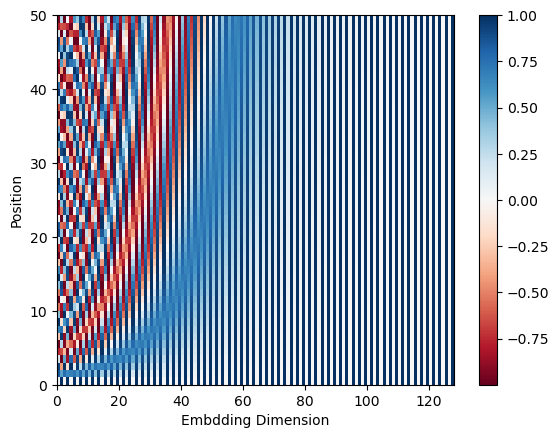

In [1]:
import math
import torch
from torch import nn
from matplotlib import pyplot as plt

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1): #임베딩 차원 d_model, 최대 시퀀스 max_len
    super().__init__()
    self.dropout=nn.Dropout(p=dropout)

    position=torch.arange(max_len).unsqueeze(1)
    div_term=torch.exp(
        torch.arange(0, d_model, 2)*(-math.log(10000.0)/d_model)
    )
    pe=torch.zeros(max_len, 1, d_model)
    pe[:,0,0::2]=torch.sin(position*div_term)
    pe[:,0,1::2]=torch.cos(position*div_term)
    self.register_buffer("pe", pe)

  def forward(self,x):
    x=x+self.pe[:,x.size(0)]
    return self.dropout(x)

encoding=PositionalEncoding(d_model=128, max_len=50)

plt.pcolormesh(encoding.pe.numpy().squeeze(),cmap="RdBu")
plt.xlabel("Embdding Dimension")
plt.ylabel("Position")
plt.xlim((0,128))
plt.colorbar()
plt.show()

토치 데이터 및 토치 텍스트 라이브러리 설치

In [1]:
import torch

# Uninstall existing torch, torchvision, torchaudio, torchtext, and numpy
!pip uninstall -y torch torchvision torchaudio torchtext numpy

# Install compatible versions of numpy, torch and torchtext
!pip install numpy==1.26.4
!pip install torch==2.2.0 --index-url https://download.pytorch.org/whl/cpu
!pip install torchtext==0.18.0 --no-deps
!pip install portalocker

# Install spacy models
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

Found existing installation: torch 2.3.0
Uninstalling torch-2.3.0:
  Successfully uninstalled torch-2.3.0
Found existing installation: torchtext 0.18.0
Uninstalling torchtext-0.18.0:
  Successfully uninstalled torchtext-0.18.0
Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-macosx_11_0_arm64.whl (13.7 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
accelerate 1.6.0 requires torch>=2.0.0, which is not installed.
sentence-transformers 5.0.0 requires torch>=1.11.0, which is not installed.
streamlit 1.32.0 requires protobuf<5,>=3.20, but you have protobuf 5.29.5 which is incompatible.
streamlit 1.32.0 requires tenacity<9,>=8.1.0, but you have tenacity 9.1.2 which is incompatible.
Lookin

7.2 데이터셋 다운로드 및 전처리

In [7]:
pip install torch==2.3.0 torchtext==0.18.0

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.0/61.0 MB 523.6 kB/s eta 0:00:00m eta 0:00:010:00:03
  Attempting uninstall: torch
    Found existing installation: torch 2.2.0
    Uninstalling torch-2.2.0:
      Successfully uninstalled torch-2.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
timm 1.0.15 requires torchvision, which is not installed.
Note: you may need to restart the kernel to use updated packages.


In [3]:
pip install torchdata==0.7.1

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 184.4/184.4 kB 560.1 kB/s eta 0:00:00 kB/s eta 0:00:01:01
  Attempting uninstall: torchdata
    Found existing installation: torchdata 0.11.0
    Uninstalling torchdata-0.11.0:
      Successfully uninstalled torchdata-0.11.0
Note: you may need to restart the kernel to use updated packages.


In [7]:
!pip install datasets transformers spacy
!python -m spacy download en_core_web_sm
!python -m spacy download de_core_news_sm

  Using cached https://github.com/explosion/spacy-models/releases/download/en_core_web_sm-3.8.0/en_core_web_sm-3.8.0-py3-none-any.whl (12.8 MB)
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 1.1 MB/s eta 0:00:00m eta 0:00:010:00:01m
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')


In [9]:
# 기존 설치된 라이브러리들 완전히 제거
!pip uninstall torch torchvision torchaudio torchtext torchdata -y

# PyTorch 2.3.0 기준
!pip install torch==2.3.0 torchvision==0.18.0 torchaudio==2.3.0

# torchtext와 torchdata를 버전에 맞춰 설치
!pip install torchdata==0.7.1 torchtext==0.18.0

Found existing installation: torch 2.2.0
Uninstalling torch-2.2.0:
  Successfully uninstalled torch-2.2.0
Found existing installation: torchtext 0.18.0
Uninstalling torchtext-0.18.0:
  Successfully uninstalled torchtext-0.18.0
Found existing installation: torchdata 0.7.1
Uninstalling torchdata-0.7.1:
  Successfully uninstalled torchdata-0.7.1
  Using cached torch-2.3.0-cp312-none-macosx_11_0_arm64.whl.metadata (26 kB)
Using cached torch-2.3.0-cp312-none-macosx_11_0_arm64.whl (61.0 MB)
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 2.3 MB/s eta 0:00:00 MB/s eta 0:00:01:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.8/1.8 MB 2.4 MB/s eta 0:00:000:00:010:00:01:01
  Using cached torchdata-0.7.1-py3-none-any.whl.metadata (13 kB)
  Using cached torchtext-0.18.0-cp312-cp312-macosx_11_0_arm64.whl.metadata (7.9 kB)
Using cached torchdata-0.7.1-py3-none-any.whl (184 kB)
Using cached torchtext-0.18.0-cp312-cp312-macosx_11_0_arm64.whl (2.1 MB)


In [1]:
# 독일어 말뭉치와 영어 말뭉치에 대해 각각 토크나이저와 어휘 사전 생성
import torch
#from torchtext.datasets import Multi30k #dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
from datasets import load_dataset
import spacy
'''
#사용자가 지정한 토크나이저를 가져오는 함수
def generate_tokens(text_iter, language):
  language_index={SRC_LANGUAGE:0, TGT_LANGUAGE:1}

  for text in text_iter:
    yield token_transform[language](text[language_index[language]])

SRC_LANGUAGE="de"
TGT_LANGUAGE="en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX=0,1,2,3
special_symbols=["<unk>", "<pad>", "<bos>", "<eos>"]
#spaCy 라이브러리로 사전 학습된 모델 -> token_transform 변수에 저장
token_transform={
    SRC_LANGUAGE:get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE:get_tokenizer("spacy", language="en_core_web_sm")
}
print("Token Transform")
print(token_transform)

vocab_transform={}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
  train_iter=Multi30k(split="train", language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
  #토큰을 인덱스로 변환시키는 함수 저장
  #언어별 어휘 사전 생성
  vocab_transform[language]=build_vocab_from_iterator( #생성된 토큰을 이용해 단어집합 생성
      generate_tokens(train_iter, language),
      min_freq=1,
      specials=special_symbols, #특수 토큰
      special_first=True #True일 때 특수 토큰을 단어 집합의 맨 앞에 추가
  )
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX)#어휘 사전에 없는 토큰인 <unk>의 인덱스를 할당

print("Vocab Transform:")
print(vocab_transform)
import torch
from datasets import load_dataset
from torchtext.data.utils import get_tokenizer
from torchtext.vocab import build_vocab_from_iterator
'''
'''# 설정값 유지
SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

# 허깅스페이스 데이터셋 로드 (에러 없이 데이터를 가져오는 핵심)
# 'bentrevett/multi30k'는 기존 torchtext의 Multi30k와 동일한 데이터
raw_datasets = load_dataset("bentrevett/multi30k")

# Hugging Face 데이터셋 사전 학습된 모델 -> token_transform 변수에 저장
token_transform = {
    SRC_LANGUAGE: get_tokenizer("spacy", language="de_core_news_sm"),
    TGT_LANGUAGE: get_tokenizer("spacy", language="en_core_web_sm")
}
print("Token Transform")
print(token_transform)


# Hugging Face 데이터셋 구조에 맞게 text[language]로 접근하도록 변경
def generate_tokens(text_iter, language):
    for example in text_iter:
        yield token_transform[language](example[language])


vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    # Multi30k(split="train") 대신 raw_datasets['train'] 사용
    train_iter = raw_datasets['train']
    #토큰을 인덱스로 변환시키는 함수 저장
    #언어별 어휘 사전 생성    
    vocab_transform[language] = build_vocab_from_iterator( #생성된 토큰을 이용해 단어집합 생성
        generate_tokens(train_iter, language),
        min_freq=1, 
        specials=special_symbols, #특수 토큰
        special_first=True #True일 때 특수 토큰을 단어 집합의 맨 앞에 추가
    )

# 6. 기본 인덱스 설정 (기존과 동일)
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    vocab_transform[language].set_default_index(UNK_IDX) #어휘 사전에 없는 토큰인 <unk>의 인덱스를 할당

print("Vocab Transform:")
print(vocab_transform)'''

OSError: dlopen(/opt/anaconda3/envs/torch310/lib/python3.10/site-packages/torchtext/lib/libtorchtext.so, 0x0006): Symbol not found: __ZN2at4_ops19empty_memory_format4callEN3c108ArrayRefINS2_6SymIntEEENS2_8optionalINS2_10ScalarTypeEEENS6_INS2_6LayoutEEENS6_INS2_6DeviceEEENS6_IbEENS6_INS2_12MemoryFormatEEE
  Referenced from: <460A46F0-1263-3987-BC76-FE095015AFEF> /opt/anaconda3/envs/torch310/lib/python3.10/site-packages/torchtext/lib/libtorchtext.so
  Expected in:     <8B7B82B6-E557-3363-B7AC-84C29F398EBA> /opt/anaconda3/envs/torch310/lib/python3.10/site-packages/torch/lib/libtorch_cpu.dylib

In [3]:
# 1. spacy 라이브러리 설치
!pip install spacy

# 2. 독일어(de)와 영어(en) 모델 다운로드 (이게 꼭 필요합니다!)
!python -m spacy download de_core_news_sm
!python -m spacy download en_core_web_sm

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 14.6/14.6 MB 2.4 MB/s eta 0:00:00m eta 0:00:010:00:01
✔ Download and installation successful
You can now load the package via spacy.load('de_core_news_sm')
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 2.3 MB/s eta 0:00:00m eta 0:00:010:00:01
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')


In [3]:
import torch
from datasets import load_dataset
import spacy
from collections import Counter
from torch.vocab import vocab as build_torch_vocab

# 1. 설정 (기존과 동일)
SRC_LANGUAGE = "de"
TGT_LANGUAGE = "en"
UNK_IDX, PAD_IDX, BOS_IDX, EOS_IDX = 0, 1, 2, 3
special_symbols = ["<unk>", "<pad>", "<bos>", "<eos>"]

# 2. 데이터셋 로드 (허깅스페이스)
print("데이터셋 로드 중...")
raw_datasets = load_dataset("bentrevett/multi30k")

# 3. 토크나이저 직접 설정 (torchtext.get_tokenizer 대체)
de_nlp = spacy.load("de_core_news_sm")
en_nlp = spacy.load("en_core_web_sm")

token_transform = {
    SRC_LANGUAGE: lambda text: [tok.text for tok in de_nlp.tokenizer(text)],
    TGT_LANGUAGE: lambda text: [tok.text for tok in en_nlp.tokenizer(text)]
}

# 4. Vocab 빌드 함수 직접 구현 (build_vocab_from_iterator 대체)
def build_vocab_manual(data_iter, language):
    counter = Counter()
    for example in data_iter:
        tokens = token_transform[language](example[language])
        counter.update(tokens)
    
    # 빈도순으로 정렬된 딕셔너리 생성
    sorted_by_freq_tuples = sorted(counter.items(), key=lambda x: x[1], reverse=True)
    ordered_dict = {token: freq for token, freq in sorted_by_freq_tuples}
    
    # torch 내부의 vocab 객체 생성 (torchtext 것과 동일하게 작동)
    v = build_torch_vocab(ordered_dict, specials=special_symbols, special_first=True)
    v.set_default_index(UNK_IDX)
    return v

# 5. 어휘 사전(Vocab) 생성 실행
vocab_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    print(f"{language} 단어장 구축 중 (이건 좀 걸릴 수 있습니다)...")
    vocab_transform[language] = build_vocab_manual(raw_datasets['train'], language)

print("\n✅ [성공] 드디어 에러 없이 단어장이 생성되었습니다!")
print(f"독어(de) 사전 크기: {len(vocab_transform[SRC_LANGUAGE])}")
print(f"영어(en) 사전 크기: {len(vocab_transform[TGT_LANGUAGE])}")

ModuleNotFoundError: No module named 'spacy'

7.3 트랜스포머 모델 구성

In [11]:
import math
import torch
from torch import nn

class PositionalEncoding(nn.Module):
  def __init__(self, d_model, max_len, dropout=0.1):
    super().__init__()
    self.dropout=nn.Dropout(p=dropout)

    position=torch.arange(max_len).unsqueeze(1)
    div_term=torch.exp(
        torch.arange(0, d_model,2)*(-math.log(10000.0)/d_model)
    )
    pe=torch.zeros(max_len, 1, d_model)
    pe[:,0,0::2]=torch.sin(position*div_term)
    pe[:,0,1::2]=torch.cos(position*div_term)
    self.register_buffer("pe", pe)

  def forward(self,x):
    x=x+self.pe[:,x.size(0)]
    return self.dropout(x)

class TokenEmbedding(nn.Module):
  def __init__(self, vocab_size,emb_size):
    super().__init__()
    self.embedding=nn.Embedding(vocab_size,emb_size)
    self.emb_size=emb_size

  def forward(self, tokens):
    return self.embedding(tokens.long())*math.sqrt(self.emb_size)
#TokenEmbedding 클래스로 소스 데이터와 입력 데이터를 입력 임베딩으로 변환, src_tok_emb, tgt_tok_emb를 생성
#소스와 타킷 데이터의 어휘 사전 크기 입력 -> 트랜스포머 임베딩 크기로 변환
class Seq2SeqTransformer(nn.Module):
  def __init__(
      self,
      num_encoder_layers,
      num_decoder_layers,
      emb_size,
      max_len,
      nhead,
      src_vocab_size,
      tgt_vocab_size,
      dim_feedforward,
      dropout=0.1,
               ):
    super().__intit__()
    self.src_tok_emb=TokenEmbedding(src_vocab_size, emb_size)
    self.tgt_tok_emb=TokenEmbedding(tgt_vocab_size, emb_size)
    self.positional_encoding=PositionalEncoding(d_model=emb_size, max_len=max_len, dropout=dropout)
    self.transformer=nn.Transformer( #트랜스포머 블록
        d_model=emb_size,
        nhead=nhead,
        num_encoder_layers=num_encoder_layers,
        num_decoder_layers=num_decoder_layers,
        dim_feedforward=dim_feedforward,
        dropout=dropout
        )
    self.generator=nn.Linear(emb_size, tgt_vocab_size)

  def forward(self, src, tgt, src_mask, tgt_mask, src_padding_mask, tgt_padding_mask,memory_key_padding_mask,):
    src_emb=self.positional_encoding(self.src_tok_emb(src))
    tgt_emb=self.positional_encoding(self.tgt_tok_emb(tgt))
    outs=self.transformer(
        src=src_emb,
        tgt=tgt_emb,
        src_mask=src_mask,
        tgt_mask=tgt_mask,
        memory_mask=None,
        src_key_padding_mask=src_padding_mask,
        tgt_key_padding_mask=tgt_padding_mask,
        memory_key_padding_mask=memory
    )
    return self.generator(outs) #T의 decoder에서 산출되는 벡터를 선형 변환->어휘 사전에 대한 로짓

    def encode(self, src, src_mask):
        return self.transformer.encoder(
        self.positional_encoding(self.src_tok_emb(src)),
        src_mask)
    
    def decode(self, tgt, memory, tgt_mask):
        return self.transformer.decoder(self.positional_encoding(self.tgt_tok_emb(tgt)), memory, tgt_mask)


######*파이토치의 트랜스포머 클래스

In [ ]:
transformer=torch.nn.Transformer(
    d_model=512, #임베딩 차원 : 트랜스포머 모델의 입력과 출력 차원의 크기 & ==임베딩 차원 크기
    nhead=8, #멀티 헤드 어텐션 헤드의 개수, 모델의 병렬 처리 능력에 비례, but 모델 매개변수의 수도 증가
    num_encoder_layers=6, #인코더 계층 개수 : 인코더 계층 수
    num_decoder_layers=6, #디코더 계층 개수 : 디코더 계층 수 // 모델의 복잡도와 성능에 영향
    dim_feedforward=2048, #순방향 신경망 크기 : 순방향 신경망의 은닉층 크기 정의, 순방향 신경망 계층은 트랜스포머 계층의 각 입력 위치에 독립적으로 적용
    dropout=0.1, #드롭아웃
    activation=torch.nn.functional.relu, #활성화 함수
    layer_norm_eps=1e-05, #계층 정규화 입실론: 계층 정규화 수행시 분모에 더해지는 입실론 값
)

#####*트랜스포머 순방향 method

In [ ]:
output=transformer.forward(
    src,
    tgt, #소스와 타깃 : [소스(타깃) 시퀸스 길이, 배치 크기, 임베딩 차원]형태의 데이터를 받음
    src_mask=None,
    tgt_mask=None, #소스 마스크와 타깃 마스크 : [소스(타깃) 시퀸스 길이,시퀸스 길이]
    memory_mask=None,  #인코더 출력의 마스크 : [타깃 시퀸스 길이, 소스 시퀸스 길이],=0이면 어텐션 연산X
    #key padding : memory_key_padding_mask과 src_key_padding_mask는 동일한 형태의 데이터 입력받음
    src_key_padding_mask=None,
    tgt_key_padding_mask=None,
    memory_key_padding_mask=None,
    #마스크값 : 0>해당 위치 모든 입력 단어가 동일한 가중치&어텐션O,1>모든 입력 단어가 가중치 0&어텐션X, -inf>어텐션 연산 결과에 0으로 가중치, 마스킹된 위치의 정보를 모델이 무시
)

#####7.4 트랜스포머 모델 구조

In [13]:
from torch import optim

BATCH_SIZE=128
DEVICE="mps" if torch.backends.mps.is_available() else "cpu"

model=Seq2SeqTransformer(
    num_encoder_layers=3,
    num_decoder_layers=3,
    emb_size=512,
    max_len=512,
    nhead=8,
    src_vocab_size=len(vocab_transform[SRC_LANGUAGE]),
    tgt_vocab_size=len(vocab_transform[TGT_LANGUAGE]),
    dim_feedforward=512,
).to(DEVICE)
criterion = nn.CrossEntropyLoss(ignore_index=PAD_IDX).to(DEVICE)
optimizer = optim.Adam(model.parameters())

for main_name, main_module in model.named_children():
    print(main_name)
    for sub_name, sub_module in main_module.named_children():
        print("ㄴ", sub_name)
        for ssub_name, ssub_module in sub_module.named_children():
            print("| ㄴ", ssub_name)
            for sssub_name, sssub_module in ssub_module.named_children():
                print("| | ㄴ", sssub_name)

NameError: name 'vocab_transform' is not defined

- Seq2SeqTransformer클래스 : 입력 임베딩+위치인코딩+트랜스포머 블록+로짓 생성
- 인코더와 디코더는 각각 3개
- 손실 함수 : 교차 엔트로피 함수
- ignore_index에 PAD_IDX 할당

#####7.5 배치 데이터 생성

In [21]:
from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence

from torch.utils.data import DataLoader
from torch.nn.utils.rnn import pad_sequence
# 여러개의 전처리 함수를 인자로 받아 적용하는 함수
def sequential_transforms(*transforms):
    def func(txt_input):
        for transform in transforms:
            txt_input = transform(txt_input)
        return txt_input
    return func

def input_transform(token_ids): #특수 토큰 할당, BOS_IDX, EOS_IDX
    return torch.cat(
        (torch.tensor([BOS_IDX]),
         torch.tensor(token_ids),
         torch.tensor([EOS_IDX]))
    )
#집합함수, 배치 단위로 데이터 처리
def collator(batch):
    src_batch, tgt_batch = [], []
    for src_sample, tgt_sample in batch: #문자열 끝의 개행 문자 (\n)제거
        src_batch.append(text_transform[SRC_LANGUAGE](src_sample.rstrip("\n")))
        tgt_batch.append(text_transform[TGT_LANGUAGE](tgt_sample.rstrip("\n")))
    #src와 tgt 시퀀스를 패딩
    src_batch = pad_sequence(src_batch, padding_value=PAD_IDX)
    tgt_batch = pad_sequence(tgt_batch, padding_value=PAD_IDX)
    return src_batch, tgt_batch

text_transform = {}
for language in [SRC_LANGUAGE, TGT_LANGUAGE]:
    text_transform[language] = sequential_transforms(
        token_transform[language], #각 문장 인덱스화
        vocab_transform[language], #각 토큰 인덱스화
        input_transform #특수 토큰 할당, BOS_IDX, EOS_IDX
    )
#데이터세트를 데이터로더에 적용
data_iter = Multi30k(split='valid', language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
#(패딩이 적용된 소스, 패딩이 적용된 타깃) 튜플을 반환
dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)
source_tensor, target_tensor = next(iter(dataloader))

print("(source, target):")
print(next(iter(data_iter)))

print("source_batch:", source_tensor.shape)
print(source_tensor)

print("target_batch:", target_tensor.shape)
print(target_tensor)

NameError: name 'SRC_LANGUAGE' is not defined

#####7.6 어텐션 마스크 생성

In [19]:
#마스크 생성 함수, s*s 크기의 마스크 생성
def generate_square_subsequent_mask(s):
    # 1로 채워진 행렬 -> 상삼각행렬 -> 전치
    mask = (torch.triu(torch.ones((s,s), device=DEVICE)) == 1).transpose(0,1)
    mask = (
        mask.float()
        .masked_fill(mask == 0, float('-inf')) #0이면 -inf로 > 셀프 어텐션에서 타깃 입력 시퀀스를 제외시키는 역할
        .masked_fill(mask == 1, float(0.0)) #1이면 0.0으로 > 셀프 어텐션에 참조되는 시퀀스를 가리킴
    )
    return mask
#타깃 시퀸스의 패딩 마스크 생성
def create_mask(src, tgt):
    src_seq_len = src.shape[0]
    tgt_seq_len = tgt.shape[0]

    tgt_mask = generate_square_subsequent_mask(tgt_seq_len)
    src_mask = torch.zeros((src_seq_len, src_seq_len), device=DEVICE).type(torch.bool)

    src_padding_mask = (src == PAD_IDX).transpose(0,1)
    tgt_padding_mask = (tgt == PAD_IDX).transpose(0,1)
    return src_mask, tgt_mask, src_padding_mask, tgt_padding_mask

#b4 패딩 마스크 생성, 토큰 순서 한 칸 시프트 > 이전 토큰들로 다음 토큰 예측하도록
target_input = target_tensor[:-1, :]
target_out = target_tensor[1:, :]

source_mask, target_mask, source_padding_mask, target_padding_mask = create_mask(
    source_tensor, target_input)
# source_mask : 셀프 어텐션 과정에서 참조되는 소스 데이터의 시튄스 범위
# False : 해당 위치는 셀프 어텐션에 참조되는 토큰 / True : 어텐션에 제외되는 토큰
print("source_mask:", source_mask.shape)
print(source_mask)
# i번째 벡터는 i+1 이상의 키 벡터에 대해 어텐션 수행 X -> 이전 키에 대해서만 참조하는 특성
print("target_mask:", target_mask.shape)
print(target_mask)
# 소스(타깃) 배치 데이터에서 텍스트 토큰이 존재하는지 여부
# False : 해당 토큰 인덱스 존재 / True : 해당 토큰 인덱스가 패딩 토큰으로 채워짐
print("source_padding_mask:", source_padding_mask.shape)
print(source_padding_mask)
print("target_padding_mask:", target_padding_mask.shape)
print(target_padding_mask)

NameError: name 'target_tensor' is not defined

#####7.7 모델 학습 및 평가

In [17]:
# 모델 학습 및 평가를 위한 함수 > 소스와 타깃 데이터를 입력받아 collator로 문장들을 토큰화&인덱스로 변환
def run(model, optimizer, criterion, split):
    model.train() if split == 'train' else model.eval()
    data_iter = Multi30k(split=split, language_pair=(SRC_LANGUAGE, TGT_LANGUAGE))
    dataloader = DataLoader(data_iter, batch_size=BATCH_SIZE, collate_fn=collator)

    losses = 0
    for source_batch, target_batch in dataloader:
        source_batch = source_batch.to(DEVICE)
        target_batch = target_batch.to(DEVICE)

        target_input = target_batch[:-1, :]
        target_output = target_batch[1:, :]
        #create_mask는 입력 패딩 마스크와 어텐션 마스크 생성
        src_mask, tgt_mask, src_padding_mask, tgt_padding_mask = create_mask(
            source_batch, target_input
        )

        logits = model(
            src=source_batch,
            tgt=target_input,
            src_mask=src_mask,
            tgt_mask=tgt_mask,
            src_padding_mask=src_padding_mask,
            tgt_padding_mask=tgt_padding_mask,
            memory_key_padding_mask=src_padding_mask,
        )

        optimizer.zero_grad()
        loss = criterion(
            logits.reshape(-1, logits.shape[-1]),
            target_output.reshape(-1))
        if split == 'train':
            loss.backward()
            optimizer.step()
        losses += loss.item()

    return losses / len(list(dataloader))

for epoch in range(5):
    train_loss = run(model, optimizer, criterion, 'train')
    val_loss = run(model, optimizer, criterion, 'valid')
    print(f"Epoch: {epoch+1}, Train loss: {train_loss:.3f}, Val loss: {val_loss:.3f}")

NameError: name 'model' is not defined

#####7.8 트랜스포머 모델 번역 결과

In [15]:
# 그리드 디코딩 방식 : 디코더 net가 생성한 확률 분포에서 가장 높은 확률을 가지는 단어 선택하여 디코딩 진행
# 현재까지 예측된 ㅌ큰 > 다음 토큰 예측
def greedy_decode(model, source_tensor, source_mask, max_len, start_symbol):
    source_tensor = source_tensor.to(DEVICE)
    source_mask = source_mask.to(DEVICE)
    #model.encode : 소스 문장에 대한 인코딩 수행 > 마지막 인코더 트랜스포머 블록의 벡터 ㅜ출
    memory = model.encode(source_tensor, source_mask) # 마지막 인코더 트랜스포머 블록의 벡터
    #source_tensor(소스 문장을 토큰 인덱스로 표현)생성, source_mask : 모든 토큰이 어텐션이 되도록 -> 0으로 설정
    ys = torch.ones(1, 1).fill_(start_symbol).type(torch.long).to(DEVICE)
    for i in range(max_len - 1):
        memory = memory.to(DEVICE)
        target_mask = generate_square_subsequent_mask(ys.size(0))
        target_mask = target_mask.type(torch.bool).to(DEVICE)

        out = model.decode(ys, memory, target_mask) #어휘 사전에서 가장 높은 토큰 인덱스를 찾는다
        out = out.transpose(0, 1)
        prob = model.generator(out[:, -1])
        _, next_word = torch.max(prob, dim=1)
        next_word = next_word.item

        ys = torch.cat(
            [ys, torch.ones(1, 1).type_as(source_tensor.data).fill_(next_word())], dim=0
        )
        if next_word == EOS_IDX:
            break
    return ys

def translate(model, source_sentence):
    model.eval()
    source_tensor = text_transform[SRC_LANGUAGE](source_sentence).view(-1, 1)
    num_tokens = source_tensor.shape[0]
    src_mask = (torch.zeros(num_tokens, num_tokens)).type(torch.bool)
    tgt_tokens = greedy_decode(
        model, source_tensor, src_mask, max_len=num_tokens + 5, start_symbol=BOS_IDX
    ).flatten()
    output = vocab_transform[TGT_LANGUAGE].lookup_tokens(list(tgt_tokens.cpu().numpy()))

    return " ".join(output).replace("", "").replace("", "")

output_oov = translate(model, "Eine Gruppe von Menschen steht vor einem Iglu .")
output = translate(model, "Eine Gruppe von Menschen steht vor einem Gebäude .")
print(output_oov)
print(output)


NameError: name 'model' is not defined